In [10]:
from pylib.setup import *
setup_notebook()

from assumptions import demand, solar_tech, wind_tech, battery
from model import GridSupply, VESupply

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load profile and exports — VE scenario

Shows hour by hour how the datacenter's 1 GW demand is met in the VE scenario.
Each hour is decomposed into four sources: solar, wind, battery (discharge) and grid import.
Below zero, surplus production exported at spot price is shown, capped at the grid connection capacity $(1-x) \cdot P = 500$ MW.

*`1. input data`*

*Loads the three 8,760-row input files and normalises to capacity factors and EUR/MWh.*

In [11]:
# 1. inputdata
pat           = pathlib.Path('variation_patterns')
_solar_cap_mw = 4_955.5428
_wind_cap_mw  = 4_878.483

solar_cf = np.loadtxt(pat / 'PV_VE_2025_2026.txt') / _solar_cap_mw
wind_cf  = np.loadtxt(pat / 'WL_VE_2025_2026.txt') / _wind_cap_mw
prices   = np.loadtxt(pat / 'wp_2025_2026.txt')    / 7.46

print(f'solar_cf  mean={solar_cf.mean():.3f}  max={solar_cf.max():.3f}')
print(f'wind_cf   mean={wind_cf.mean():.3f}  max={wind_cf.max():.3f}')
print(f'prices    mean={prices.mean():.1f}  min={prices.min():.1f}  max={prices.max():.1f} EUR/MWh')

solar_cf  mean=0.103  max=0.750
wind_cf   mean=0.229  max=0.816
prices    mean=81.6  min=-30.7  max=583.5 EUR/MWh


*`2. build model and load solution`*

*Initialises model layers, loads capacities from `runs/ve_solution.json`, and loads the saved LP dispatch arrays from `runs/ve_lp_arrays.npz` — no optimisation or LP re-solve required. Run `2_model.ipynb` to regenerate both files.*

In [12]:
# 2. byg model og indlæs løsning
grid = GridSupply(prices, demand)
ve   = VESupply(solar_cf, wind_cf, solar_tech, wind_tech, battery, demand, prices=prices)
ve.load()            # capacities from runs/ve_solution.json
ve.load_lp_arrays()  # LP dispatch from runs/ve_lp_arrays.npz — no re-solve

c_solar, c_wind, batt_power, batt_energy = ve.solution
print(f'  Solkraft : {c_solar:,.0f} MW')
print(f'  Vindkraft: {c_wind:,.0f} MW')
print(f'  Batteri  : {batt_power:,.0f} MW / {batt_energy:,.0f} MWh')

  Solkraft : 6,364 MW
  Vindkraft: 3,211 MW
  Batteri  : 2,374 MW / 28,494 MWh


*`3. helper functions`*

*`dispatch_detail`, `aggregate_dispatch` and `plot_dispatch` are loaded from `pylib/ve_dispatch.py` via `setup_notebook()`.*

In [13]:
# 3. hjælpefunktioner
# dispatch_detail, aggregate_dispatch, plot_dispatch injected by setup_notebook()

# ── compute ───────────────────────────────────────────────────────────────────
dates = pd.date_range('2025-01-01', periods=8760, freq='h')
d     = dispatch_detail(ve, solar_cf, wind_cf)

print(f"Solkraft til forbrug  : {d['pv'].sum()/1e6:.2f} TWh/år")
print(f"Vindkraft til forbrug : {d['wind'].sum()/1e6:.2f} TWh/år")
print(f"Batteri til forbrug   : {d['battery'].sum()/1e6:.2f} TWh/år")
print(f"Netimport             : {d['grid'].sum()/1e6:.2f} TWh/år")
print(f"Eksport               : {d['exported'].sum()/1e6:.2f} TWh/år")

Solkraft til forbrug  : 2.03 TWh/år
Vindkraft til forbrug : 3.80 TWh/år
Batteri til forbrug   : 1.74 TWh/år
Netimport             : 1.19 TWh/år
Eksport               : 3.19 TWh/år


# Hourly dispatch — demand and exports

For each of the year's 8,760 hours, the 1 GW demand is decomposed into solar, wind, battery and grid import (above zero). Grid exports at spot price are shown below zero.

*`4. hourly plot`*

*Stacked area plot across the year's 8,760 hours with monthly labels on the x-axis; exports shown as negative area.*

In [14]:
# # 4. timeplot
# plot_dispatch(d, dates, ylabel='MW',
#               save_path='figures/3_ve_dispatch_hourly.png')

# Aggregated profiles

Same breakdown as the hourly plot, averaged to day, week and month to highlight seasonal patterns without hourly noise.

*`5. daily average`*

*Mean MW across each of the 365 days.*

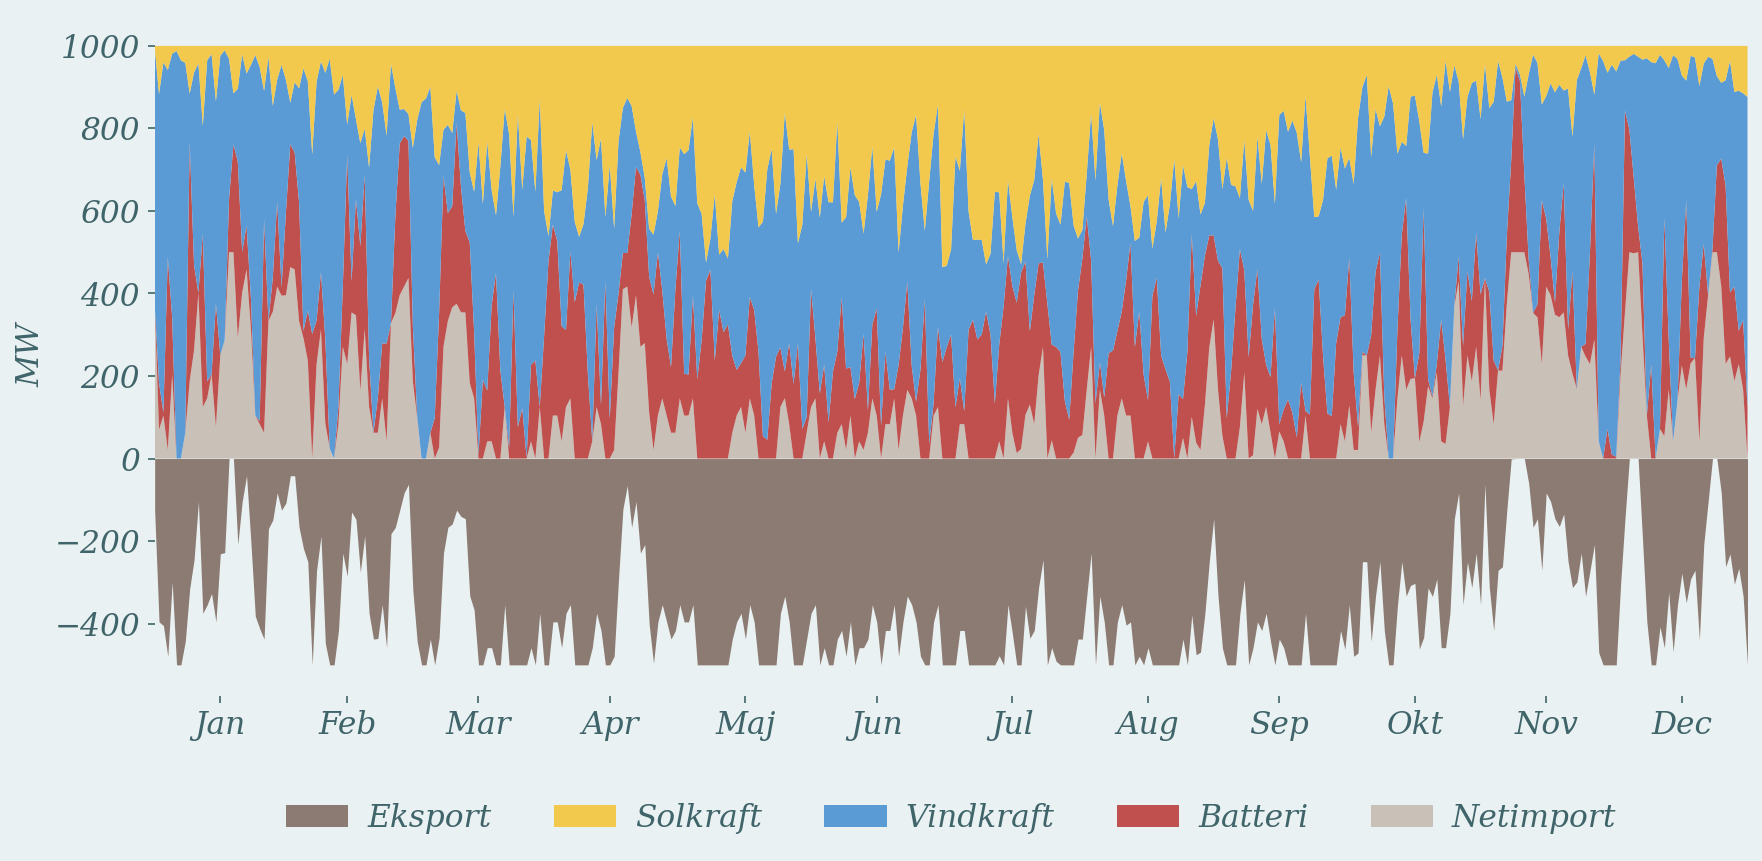

(<Figure size 1800x900 with 1 Axes>, <Axes: ylabel='MW'>)

In [15]:
# 5. daglig aggregering
d_day, idx_day = aggregate_dispatch(d, dates, 'D')
plot_dispatch(d_day, idx_day, ylabel='MW',
              save_path='figures/3_ve_dispatch_daily.png')

*`6. weekly average`*

*Mean MW across each of the 52 weeks.*

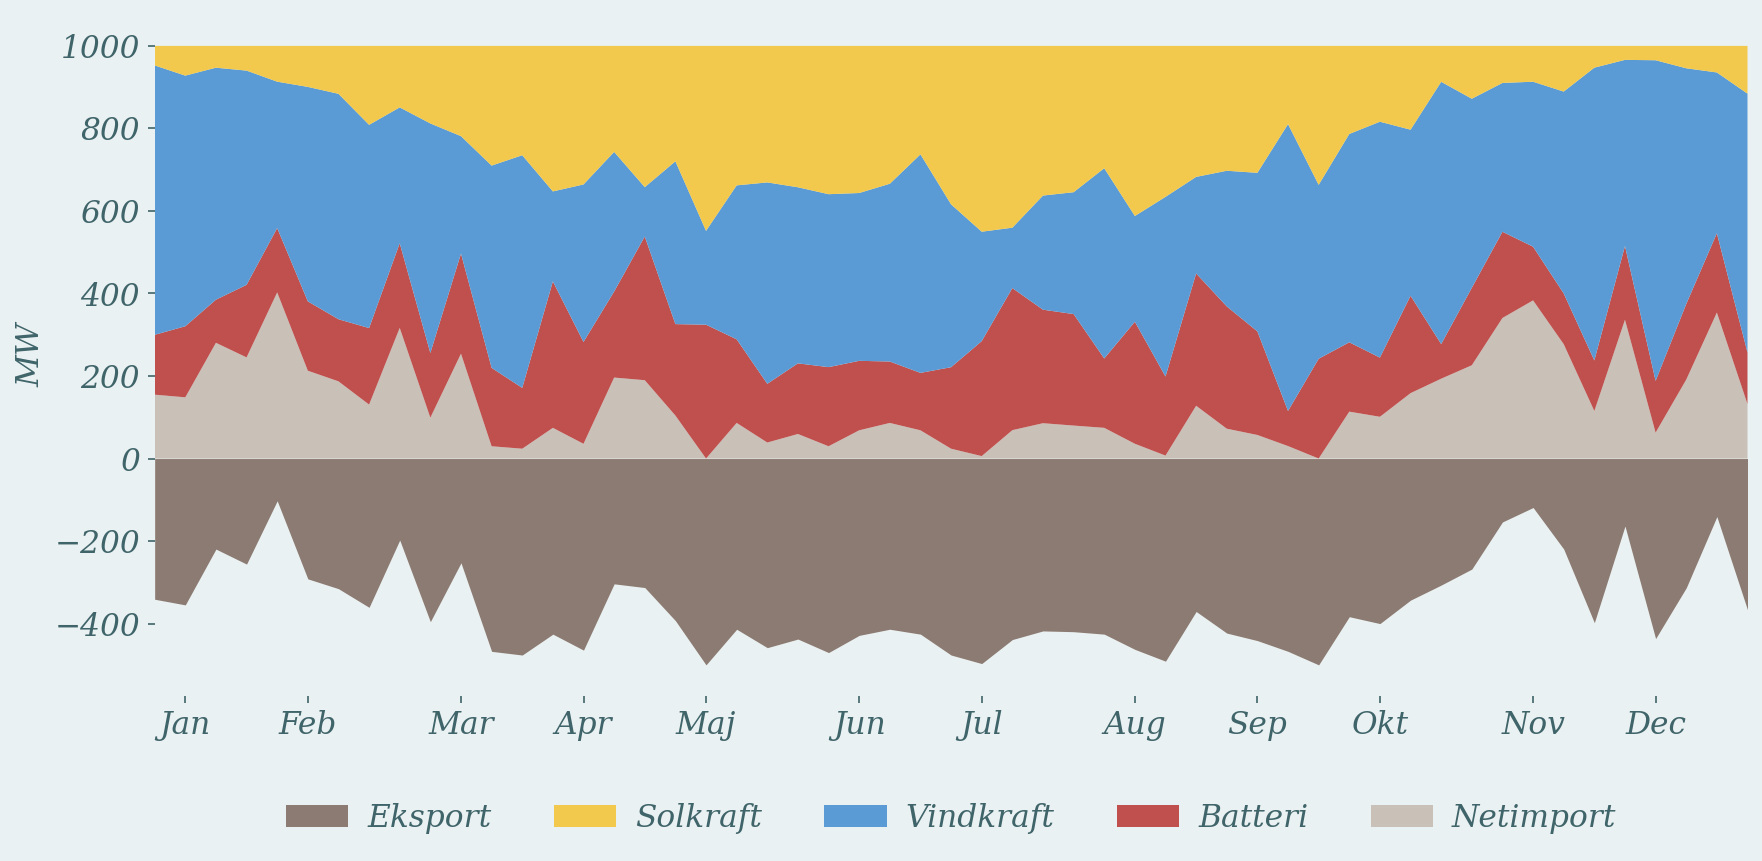

(<Figure size 1800x900 with 1 Axes>, <Axes: ylabel='MW'>)

In [16]:
# 6. ugentlig aggregering
d_week, idx_week = aggregate_dispatch(d, dates, 'W')
plot_dispatch(d_week, idx_week, ylabel='MW',
              save_path='figures/3_ve_dispatch_weekly.png')

*`7. monthly average`*

*Mean MW across each of the 12 months.*

In [17]:
# # 7. månedlig aggregering
# d_month, idx_month = aggregate_dispatch(d, dates, 'ME')
# plot_dispatch(d_month, idx_month, ylabel='MW',
#               save_path='figures/3_ve_dispatch_monthly.png')

# Battery flows and state of charge

Weekly mean MW flows (right axis): charge above zero in amber, discharge to datacenter below zero in red, discharge to grid below zero in grey (zero in current model). Weekly mean state of charge in MWh on the left axis (blue fill).

*`8. battery figure`*

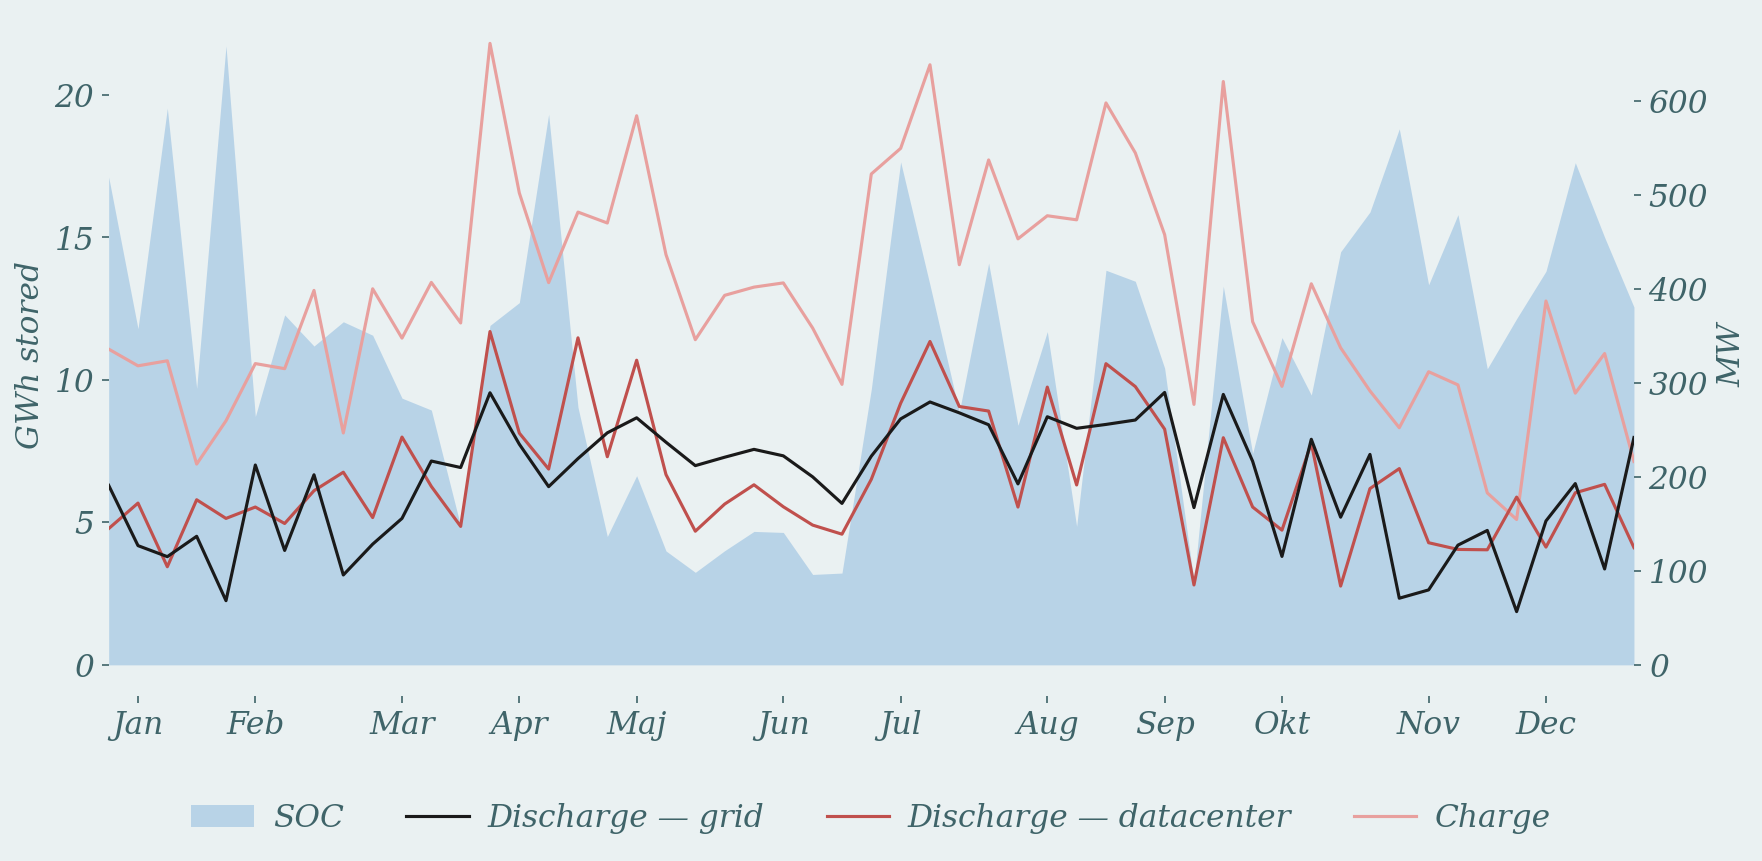

(<Figure size 1800x900 with 2 Axes>,
 (<Axes: ylabel='GWh stored'>, <Axes: ylabel='MW'>))

In [18]:
# 8. battery figure
batt          = battery_detail(ve, solar_cf, wind_cf)
batt_week, idx_week = aggregate_dispatch(batt, dates, 'W')
plot_battery(batt_week, idx_week, save_path='figures/3_ve_battery.png')